In [1]:
from typing import Any

import geopandas as gpd
import requests
from shapely.geometry import shape
from shapely.ops import unary_union

In [2]:
DBGT_WFS_URL = (
    "https://geomap.reteunitaria.piemonte.it/ws/siccms/"
    "coto-01/wfsg01/wfs_sicc140_edificato_dbgt"
)

In [3]:
def get_dbgt_buildings(
    boundary_geojson: dict[str, Any],
    principal_only: bool = True,
    timeout_seconds: int = 180,
) -> gpd.GeoDataFrame:
    """Download DBGT buildings intersecting an EPSG:4326 GeoJSON boundary."""

    # 1. Convert the input GeoJSON to a geometry.
    geojson_type = boundary_geojson.get("type")

    if geojson_type == "Feature":
        boundary_geometry = shape(boundary_geojson["geometry"])

    elif geojson_type == "FeatureCollection":
        geometries = [
            shape(feature["geometry"])
            for feature in boundary_geojson["features"]
        ]
        boundary_geometry = unary_union(geometries)

    else:
        boundary_geometry = shape(boundary_geojson)

    boundary = gpd.GeoDataFrame(
        geometry=[boundary_geometry],
        crs="EPSG:4326",
    )

    # 2. DBGT expects its bounding box in EPSG:3003.
    boundary_3003 = boundary.to_crs("EPSG:3003")
    min_x, min_y, max_x, max_y = boundary_3003.total_bounds

    parameters = {
        "service": "WFS",
        "version": "1.0.0",
        "request": "GetFeature",
        "typeName": "Edificato",
        "BBOX": f"{min_x},{min_y},{max_x},{max_y}",
        "outputFormat": "geojson",
    }

    # 3. Download the buildings.
    response = requests.get(
        DBGT_WFS_URL,
        params=parameters,
        timeout=timeout_seconds,
    )
    response.raise_for_status()

    features = response.json().get("features", [])

    if not features:
        return gpd.GeoDataFrame(
            geometry=[],
            crs="EPSG:4326",
        )

    buildings = gpd.GeoDataFrame.from_features(
        features,
        crs="EPSG:3003",
    )
    buildings = buildings.to_crs("EPSG:4326")

    # 4. Keep buildings intersecting the exact boundary.
    buildings = gpd.sjoin(
        buildings,
        boundary[["geometry"]],
        how="inner",
        predicate="intersects",
    )
    buildings = buildings.drop(columns="index_right")

    # Optionally remove garages, sheds and similar minor structures.
    if principal_only and "gruppo" in buildings.columns:
        is_minor = buildings["gruppo"].str.contains(
            "MINORI",
            case=False,
            na=False,
        )
        buildings = buildings[~is_minor]

    return buildings.reset_index(drop=True)

In [4]:
boundary = {
    "type": "Polygon",
    "coordinates": [[
        [7.660, 45.055],
        [7.685, 45.055],
        [7.685, 45.070],
        [7.660, 45.070],
        [7.660, 45.055],
    ]],
}

buildings = get_dbgt_buildings(boundary)

print(f"Retrieved {len(buildings)} buildings")
print(buildings.columns.tolist())

Retrieved 4294 buildings
['geometry', 'codice_intesa', 'gruppo', 'descrizione', 'categoria_uso', 'epoca_costruzione', 'numero_piani', 'altezza_edificio', 'valenza_storica', 'nome', 'qt_gronda', 'qt_suolo', 'transito']


In [5]:
from pathlib import Path

import geopandas as gpd

In [6]:
def read_boundary_and_create_dbgt_bbox(
    geojson_path: str | Path,
) -> tuple[gpd.GeoDataFrame, tuple[float, float, float, float]]:
    """Read a boundary GeoJSON and create its DBGT bbox in EPSG:3003."""

    boundary = gpd.read_file(geojson_path)

    if boundary.empty:
        raise ValueError(f"No geometry found in {geojson_path}")

    if boundary.crs is None:
        raise ValueError(f"The GeoJSON has no CRS: {geojson_path}")

    # Keep the original boundary for later exact spatial filtering.
    boundary = boundary.to_crs("EPSG:4326")

    # DBGT's WFS expects its bbox in EPSG:3003.
    boundary_dbgt = boundary.to_crs("EPSG:3003")
    min_x, min_y, max_x, max_y = boundary_dbgt.total_bounds

    bbox = (
        float(min_x),
        float(min_y),
        float(max_x),
        float(max_y),
    )

    return boundary, bbox

In [16]:
def read_geojson_bbox(
    geojson_path: str | Path,
) -> dict:
    """Read a GeoJSON and return its bounding box as a GeoJSON Polygon."""
    boundary_gdf = gpd.read_file(geojson_path)
    boundary_gdf = boundary_gdf.to_crs("EPSG:4326")
    min_x, min_y, max_x, max_y = boundary_gdf.total_bounds
    boundary = {
        "type": "Polygon",
        "coordinates": [[
            [min_x, min_y],
            [max_x, min_y],
            [max_x, max_y],
            [min_x, max_y],
            [min_x, min_y],
        ]],
    }
    return boundary


print(torino_dbgt_bbox)
print(torino_bbox_parameter)

torino_boundary = read_geojson_bbox(
    "../../cim-database/torino_boundary.geojson"
)
print(torino_boundary)

(1388018.6141040951, 4984618.356736848, 1403477.104240722, 4999414.714733464)
1388018.614,4984618.357,1403477.104,4999414.715
{'type': 'Polygon', 'coordinates': [[[np.float64(7.5778348), np.float64(45.0067924)], [np.float64(7.7733388), np.float64(45.0067924)], [np.float64(7.7733388), np.float64(45.1402175)], [np.float64(7.5778348), np.float64(45.1402175)], [np.float64(7.5778348), np.float64(45.0067924)]]]}


In [17]:
torino_buildings = get_dbgt_buildings(torino_boundary)

print(f"Retrieved {len(torino_buildings)} buildings")
print(torino_buildings.columns.tolist())

Retrieved 70513 buildings
['geometry', 'codice_intesa', 'gruppo', 'descrizione', 'categoria_uso', 'epoca_costruzione', 'numero_piani', 'altezza_edificio', 'valenza_storica', 'nome', 'qt_gronda', 'qt_suolo', 'transito']


In [19]:
torino_buildings.head(3)

,geometry,codice_intesa,gruppo,descrizione,categoria_uso,epoca_costruzione,numero_piani,altezza_edificio,valenza_storica,nome,qt_gronda,qt_suolo,transito
0,"POLYGON ((7.64752 45.02076, 7.64766 45.02071, ...",020102,EDIFICI PRINCIPALI,generica,residenziale,1971 - 1980,6+1,25.75,non monumentale,,264.35,238.60,
1,"POLYGON ((7.67665 45.10129, 7.67678 45.10128, ...",020102,EDIFICI PRINCIPALI,generica,residenziale,1961 - 1970,6,21.74,non monumentale,,263.23,241.49,
2,"POLYGON ((7.64601 45.02389, 7.64614 45.02385, ...",020102,EDIFICI PRINCIPALI,generica,residenziale,1981 - 1990,6+1,24.68,non monumentale,,265.60,240.92,


In [21]:
import json

with open("../../cim-database/torino_boundary.geojson", encoding="utf-8") as file:
    torino_official_boundary = json.load(file)

torino_buildings = get_dbgt_buildings(
    torino_official_boundary,
    principal_only=True,
)

print(len(torino_buildings))

70509


In [ ]:
torino_bui

In [22]:
import geopandas as gpd
import pandas as pd

In [23]:
def retrieve_torino_addresses(
    csv_url: str,
    longitude_column: str,
    latitude_column: str,
) -> gpd.GeoDataFrame:
    """Download Torino address points from an official CSV."""

    addresses = pd.read_csv(
        csv_url,
        sep=None,
        engine="python",
    )

    addresses[longitude_column] = pd.to_numeric(
        addresses[longitude_column],
        errors="coerce",
    )
    addresses[latitude_column] = pd.to_numeric(
        addresses[latitude_column],
        errors="coerce",
    )

    addresses = addresses.dropna(
        subset=[longitude_column, latitude_column]
    )

    return gpd.GeoDataFrame(
        addresses,
        geometry=gpd.points_from_xy(
            addresses[longitude_column],
            addresses[latitude_column],
        ),
        crs="EPSG:4326",
    )

In [25]:
addresses = retrieve_torino_addresses(
    csv_url="../../datalake/civici_WGS84_EPSG4326_csv_202211.csv",
    longitude_column="COORDINATA_X",
    latitude_column="COORDINATA_Y",
)

print(addresses.columns.tolist())

['\ufeffCOD_CIVICO', 'COMUNE', 'VIA', 'CIVICO', 'CIRCOSCRIZIONE', 'CAP', 'COORDINATA_X', 'COORDINATA_Y', 'geometry']


In [26]:
def assign_addresses_to_buildings(
    buildings: gpd.GeoDataFrame,
    addresses: gpd.GeoDataFrame,
    street_column: str,
    number_column: str,
    maximum_distance_m: float = 30,
) -> gpd.GeoDataFrame:
    """Assign each address point to its nearest building."""

    result = buildings.copy().reset_index(drop=True)
    result["building_id"] = result.index

    # Distances must be calculated in metres.
    buildings_metric = result.to_crs("EPSG:32632")
    addresses_metric = addresses.to_crs("EPSG:32632").copy()

    addresses_metric["address_id"] = addresses_metric.index

    matched = gpd.sjoin_nearest(
        addresses_metric,
        buildings_metric[["building_id", "geometry"]],
        how="inner",
        max_distance=maximum_distance_m,
        distance_col="distance_to_building_m",
    )

    # Handle the rare case where one address is equally close to two buildings.
    matched = matched.sort_values(
        ["address_id", "distance_to_building_m"]
    )
    matched = matched.drop_duplicates(
        subset="address_id",
        keep="first",
    )

    matched["full_address"] = (
        matched[street_column].fillna("").astype(str).str.strip()
        + " "
        + matched[number_column].fillna("").astype(str).str.strip()
    ).str.strip()

    matched = matched[matched["full_address"] != ""]

    # One building can receive several distinct addresses.
    addresses_per_building = (
        matched.groupby("building_id")["full_address"]
        .agg(lambda values: list(dict.fromkeys(values)))
        .rename("addresses")
    )

    result = result.merge(
        addresses_per_building,
        on="building_id",
        how="left",
    )

    result["addresses"] = result["addresses"].apply(
        lambda value: value if isinstance(value, list) else []
    )

    return result
    

In [27]:
buildings_with_addresses = assign_addresses_to_buildings(
    buildings=torino_buildings,
    addresses=addresses,
    street_column="VIA",
    number_column="CIVICO",
)

buildings_with_addresses[
    ["building_id", "addresses", "geometry"]
].head()

,building_id,addresses,geometry
0,0,"[VIA PIACENZA 13, VIA PIACENZA 17, VIA PIACENZ...","POLYGON ((7.64752 45.02076, 7.64766 45.02071, ..."
1,1,[VIA ROCCAVIONE CONTE DI 74],"POLYGON ((7.67665 45.10129, 7.67678 45.10128, ..."
2,2,[CORSO TRAIANO 69],"POLYGON ((7.64601 45.02389, 7.64614 45.02385, ..."
3,3,[VIA VINCENZO GIOBERTI 21],"POLYGON ((7.67383 45.06102, 7.67395 45.06097, ..."
4,4,"[VIA SALVATORE FARINA 11, VIA SALVATORE FARINA...","POLYGON ((7.66142 45.04795, 7.66138 45.04791, ..."


In [28]:
buildings_with_addresses["number_of_addresses"] = (
    buildings_with_addresses["addresses"]
    .map(lambda addresses: len(addresses) if isinstance(addresses, list) else 0)
)

In [30]:
buildings_with_addresses[
    ["building_id", "addresses", "geometry","number_of_addresses"]
].head(20)

,building_id,addresses,geometry,number_of_addresses
0,0,"[VIA PIACENZA 13, VIA PIACENZA 17, VIA PIACENZ...","POLYGON ((7.64752 45.02076, 7.64766 45.02071, ...",3
1,1,[VIA ROCCAVIONE CONTE DI 74],"POLYGON ((7.67665 45.10129, 7.67678 45.10128, ...",1
2,2,[CORSO TRAIANO 69],"POLYGON ((7.64601 45.02389, 7.64614 45.02385, ...",1
3,3,[VIA VINCENZO GIOBERTI 21],"POLYGON ((7.67383 45.06102, 7.67395 45.06097, ...",1
4,4,"[VIA SALVATORE FARINA 11, VIA SALVATORE FARINA...","POLYGON ((7.66142 45.04795, 7.66138 45.04791, ...",2
5,5,[VIA CESANA 33],"POLYGON ((7.65041 45.06867, 7.65054 45.06865, ...",1
6,6,[],"POLYGON ((7.64211 45.1033, 7.64212 45.10328, 7...",0
7,7,[VIA STRADELLA 237 scala B],"POLYGON ((7.66416 45.10422, 7.66411 45.1042, 7...",1
8,8,[CORSO ALESSANDRO TASSONI 32],"POLYGON ((7.65646 45.08028, 7.65648 45.08008, ...",1
9,9,[CORSO FRANCIA 26],"POLYGON ((7.66315 45.07653, 7.66315 45.07664, ...",1


read the csv of Torino's building with addresses

In [ ]:
import json
import geopandas as gpd
import pandas as pd


buildings_csv = pd.read_csv(
    "buildings_with_addresses.csv"
)

buildings_csv["addresses"] = buildings_csv["addresses"].map(
    json.loads
)

buildings_csv["geometry"] = gpd.GeoSeries.from_wkt(
    buildings_csv["geometry"]
)

buildings_with_addresses = gpd.GeoDataFrame(
    buildings_csv,
    geometry="geometry",
    crs="EPSG:4326",
)

In [32]:
!pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 95.0 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 103.6 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 83.8 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5/5 [matplotlib] 4/5 [matplotlib]


In [33]:
import matplotlib.pyplot as plt

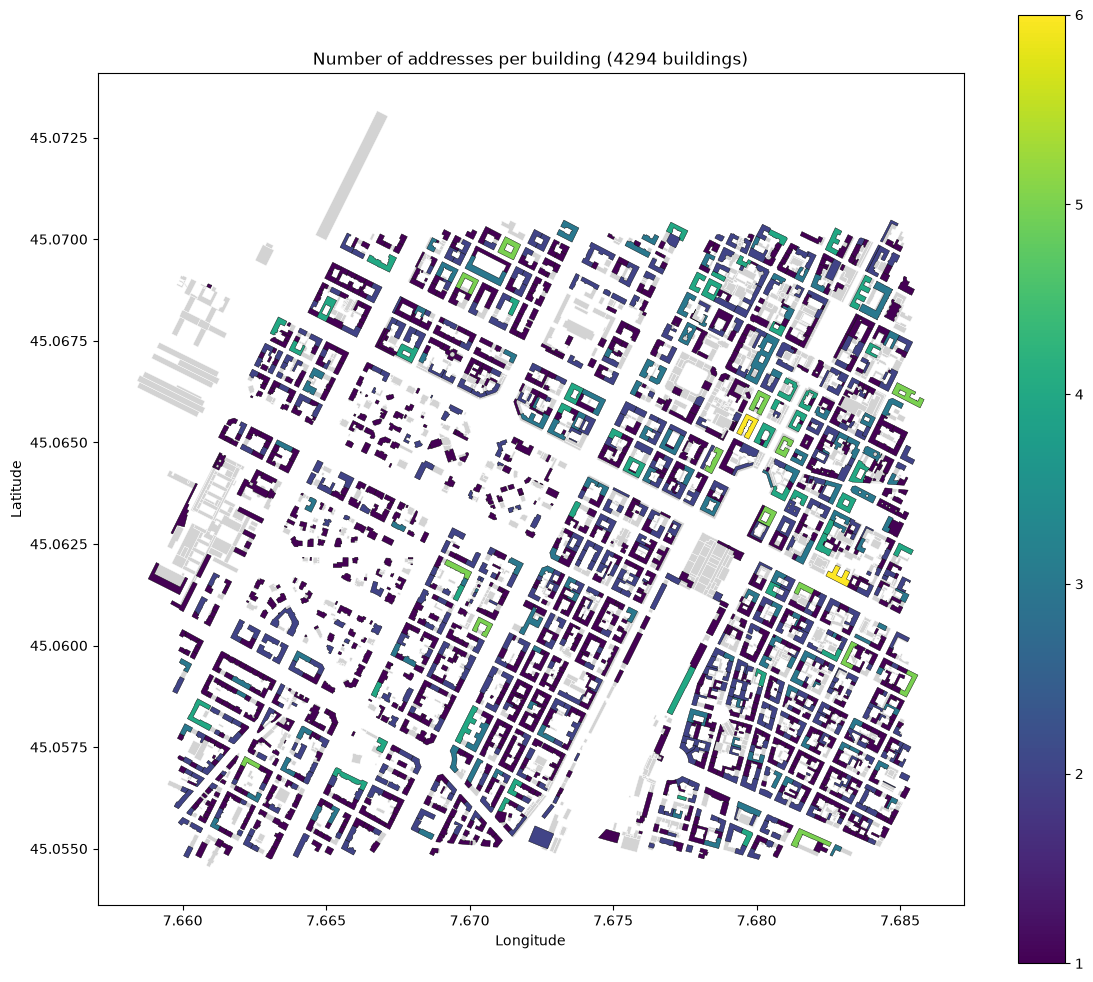

In [34]:
# Ensure the data uses longitude and latitude.
buildings_for_plot = buildings_with_addresses.to_crs("EPSG:4326")

# Select a small area of central Torino.
portion = buildings_for_plot.cx[
    7.660:7.685,
    45.055:45.070,
].copy()

figure, axis = plt.subplots(figsize=(12, 10))

# Buildings without assigned addresses.
portion[portion["number_of_addresses"] == 0].plot(
    ax=axis,
    color="lightgrey",
    edgecolor="white",
    linewidth=0.3,
)

# Buildings with addresses, coloured by address count.
portion[portion["number_of_addresses"] > 0].plot(
    ax=axis,
    column="number_of_addresses",
    cmap="viridis",
    legend=True,
    edgecolor="black",
    linewidth=0.3,
)

axis.set_title(
    f"Number of addresses per building ({len(portion)} buildings)"
)
axis.set_xlabel("Longitude")
axis.set_ylabel("Latitude")

plt.tight_layout()
plt.show()

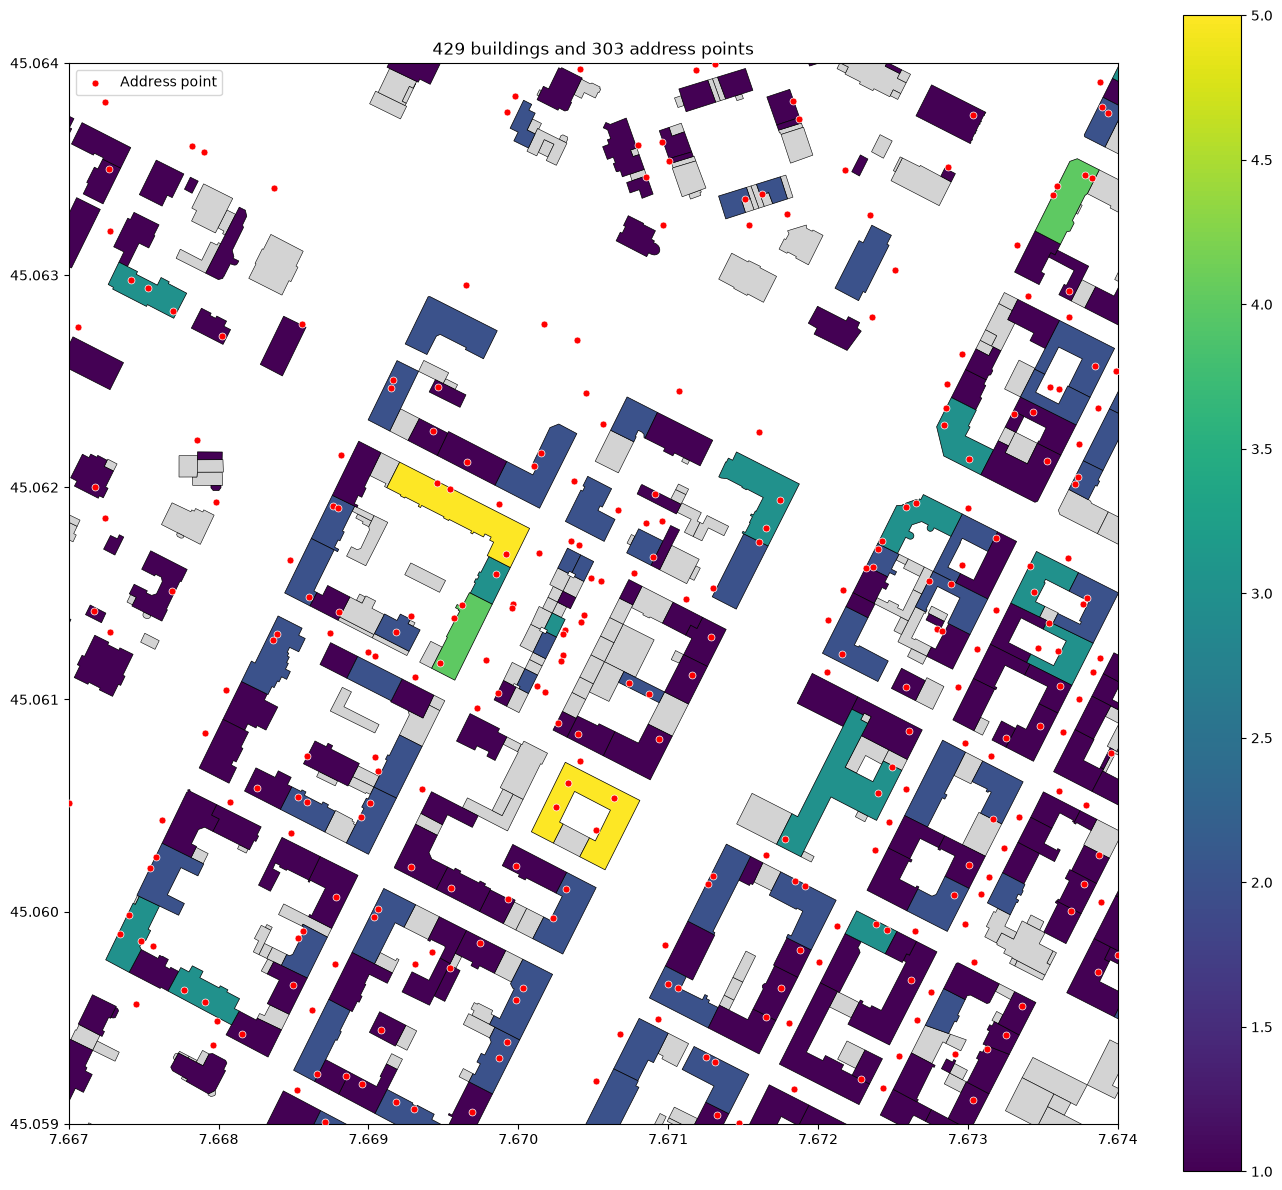

In [35]:
buildings_plot = buildings_with_addresses.to_crs("EPSG:4326")
addresses_plot = addresses.to_crs("EPSG:4326")

# Smaller area in central Torino.
min_x = 7.667
max_x = 7.674
min_y = 45.059
max_y = 45.064

building_portion = buildings_plot.cx[
    min_x:max_x,
    min_y:max_y,
].copy()

address_portion = addresses_plot.cx[
    min_x:max_x,
    min_y:max_y,
].copy()

figure, axis = plt.subplots(figsize=(14, 12))

# Buildings without an assigned address.
building_portion[
    building_portion["number_of_addresses"] == 0
].plot(
    ax=axis,
    color="lightgrey",
    edgecolor="black",
    linewidth=0.4,
)

# Buildings coloured by address count.
building_portion[
    building_portion["number_of_addresses"] > 0
].plot(
    ax=axis,
    column="number_of_addresses",
    cmap="viridis",
    legend=True,
    edgecolor="black",
    linewidth=0.5,
)

# Original address points.
address_portion.plot(
    ax=axis,
    color="red",
    marker="o",
    markersize=25,
    edgecolor="white",
    linewidth=0.5,
    label="Address point",
    zorder=3,
)

axis.set_xlim(min_x, max_x)
axis.set_ylim(min_y, max_y)
axis.set_title(
    f"{len(building_portion)} buildings and "
    f"{len(address_portion)} address points"
)
axis.legend()

plt.tight_layout()
plt.show()

In [36]:
!pip install trimesh mapbox-earcut

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 750.0/750.0 kB 28.9 MB/s  0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2/2 [mapbox-earcut]


In [37]:
from typing import Any

import geopandas as gpd
import pandas as pd
import trimesh
from shapely.geometry import MultiPolygon, Polygon

In [38]:



def extrude_building_footprints(
    buildings: gpd.GeoDataFrame,
    height_column: str = "altezza_edificio",
    ground_elevation_column: str | None = "qt_suolo",
) -> list[dict[str, Any]]:
    """Extrude building footprints into 3D meshes."""

    # Extrusion must use a metric coordinate system.
    buildings_metric = buildings.to_crs("EPSG:32632").copy()

    buildings_metric[height_column] = pd.to_numeric(
        buildings_metric[height_column],
        errors="coerce",
    )

    if ground_elevation_column is not None:
        buildings_metric[ground_elevation_column] = pd.to_numeric(
            buildings_metric[ground_elevation_column],
            errors="coerce",
        )

    extruded_buildings = []

    for building_id, building in buildings_metric.iterrows():
        height = building[height_column]
        geometry = building.geometry

        if pd.isna(height) or height <= 0:
            continue

        if geometry is None or geometry.is_empty:
            continue

        if isinstance(geometry, Polygon):
            footprint_parts = [geometry]

        elif isinstance(geometry, MultiPolygon):
            footprint_parts = list(geometry.geoms)

        else:
            continue

        part_meshes = []

        for footprint in footprint_parts:
            mesh = trimesh.creation.extrude_polygon(
                footprint,
                height=float(height),
                engine="earcut",
            )
            part_meshes.append(mesh)

        building_mesh = trimesh.util.concatenate(part_meshes)

        # Raise the building to its published ground elevation.
        if ground_elevation_column is not None:
            ground_elevation = building[ground_elevation_column]

            if not pd.isna(ground_elevation):
                building_mesh.apply_translation(
                    [0.0, 0.0, float(ground_elevation)]
                )

        extruded_buildings.append({
            "building_id": building_id,
            "height_m": float(height),
            "mesh": building_mesh,
        })

    return extruded_buildings

In [39]:
portion = buildings_with_addresses.cx[
    7.667:7.674,
    45.059:45.064,
].copy()

extruded = extrude_building_footprints(portion)

print(f"Extruded {len(extruded)} buildings")

Extruded 415 buildings


In [40]:
scene = trimesh.Scene()

for building in extruded:
    scene.add_geometry(
        building["mesh"],
        node_name=f"building_{building['building_id']}",
    )

scene.show()

In [41]:



notebook_directory = Path.cwd()
output_path = notebook_directory / "buildings_with_addresses.csv"

buildings_csv = buildings_with_addresses.copy()

# Store geometry as WKT text.
buildings_csv["geometry"] = buildings_csv.geometry.to_wkt()

# Store each address list as valid JSON.
buildings_csv["addresses"] = buildings_csv["addresses"].map(
    json.dumps
)

buildings_csv.to_csv(
    output_path,
    index=False,
)

print(f"Saved to: {output_path}")

/tmp/ipykernel_19841/2464467739.py:7: UserWarning: Geometry column does not contain geometry.
  buildings_csv["geometry"] = buildings_csv.geometry.to_wkt()


Saved to: /home/matia/Desktop/ali/CIM_wizard/env_info_modeler/core_logic/buildings_with_addresses.csv
